# Introduction

This notebook is example of running simulation with package LSolver, and also test with well-known result of statistical mechanics. Suppose overdamped Langevin equation of type
$$\dot x_t = -\frac{k}{\gamma}x_t + \sqrt{2D}\xi_t,$$
which follows from inserting the stochastic brownian particle inside harmonic potential $U(x) = \frac{1}{2}kx^2$. This equation could easily be discretized
$$x(t + \text{d}t) - x(t) = - \frac{k}{\gamma}x_t \text{d}t + \sqrt{2D\,\text{d}t}\,W_{\text{d}t}^1,$$
with $W_{\text{d}t}^1$ being random number from normal distribution $N(0,1)$.

Using the package LSolver, this particle can be simulated as follows (with selected parameters $k=1$, $\gamma = 1$, $D = 10$)

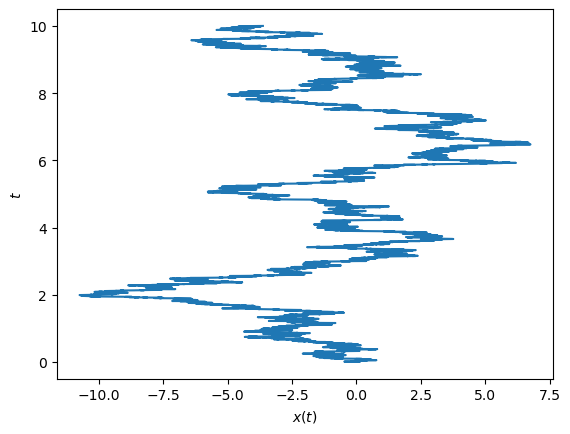

In [5]:
from LSolver import SimulationConfig, solver
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)
cfg = SimulationConfig(
    gamma = 1.0,
    k_func = lambda t: 1.0,
    D_func = lambda t: 10.0,
    t_max = 10.0,
    dt = 0.001
    )

x, y = solver(cfg, rng=rng)

fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"$x(t)$", ylabel=r"$t$")
ax.plot(x,cfg.t_array)

Instead of using the real time $t$, we can make time another stochastic variable denoted $y(t)$, with discretized equation
$$y(t+\text{d}t) - y(t) = \sqrt{2D\,\text{d}t}\, W_{\text{d}t}^1.$$
The expected behavior of this time is
$$\langle \Delta y \rangle = 0, \quad \langle(\Delta y)^2\rangle = 2D\,\text{d}t.$$
Same solution in terms of $y(t)$ looks like this.

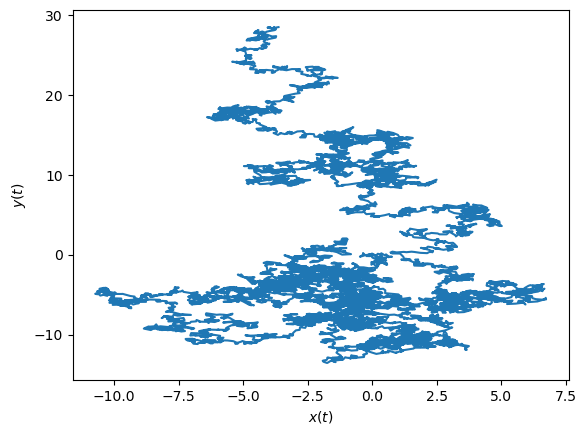

In [6]:
fig, ax = plt.subplots(1,1)
ax.set(xlabel=r"$x(t)$", ylabel=r"$y(t)$")
ax.plot(x,y)